In [1]:
# import libraries for reading data
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2
import re

<jemalloc>: Unsupported system page size


### Einlesen der Daten und Übersicht über die Daten

In [2]:
# data paths
train1_images_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_images_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_images_path = "/datasets/multi-view-pig-posture-recognition/test_images"

# csv path with row_id, image_id, width, height, bbox, class_id
train1_csv_path = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv_path = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv_path = "/datasets/multi-view-pig-posture-recognition/test.csv"

# txt file path
pig_posture_txt = "/datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt"

In [3]:
# read all files and show statistics and content of csv files, column names etc.
# read csv files
train1_df = pd.read_csv(train1_csv_path)
train2_df = pd.read_csv(train2_csv_path)
test_df = pd.read_csv(test_csv_path)

# show column names of csv files
print("\nTrain1 CSV Columns:")
print(train1_df.columns)
print("\nTrain2 CSV Columns:")
print(train2_df.columns)
print("\nTest CSV Columns:")
print(test_df.columns)

# show content of txt file
with open(pig_posture_txt, 'r') as f:
    pig_posture_content = f.read()

# show numbers of unique image_ids, row_ids in train1, train2 and test csv files
print("\nNumber of unique image_ids in Train1 CSV:", train1_df['image_id'].nunique())
print("Number of unique image_ids in Train2 CSV:", train2_df['image_id'].nunique())
print("Number of unique row_ids in Train1 CSV:", train1_df['row_id'].nunique())
print("Number of unique row_ids in Train2 CSV:", train2_df['row_id'].nunique())
print("\nPig Posture Classes:")
print(pig_posture_content)




Train1 CSV Columns:
Index(['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id'], dtype='object')

Train2 CSV Columns:
Index(['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id'], dtype='object')

Test CSV Columns:
Index(['row_id', 'image_id', 'width', 'height', 'bbox'], dtype='object')

Number of unique image_ids in Train1 CSV: 3090
Number of unique image_ids in Train2 CSV: 3150
Number of unique row_ids in Train1 CSV: 22934
Number of unique row_ids in Train2 CSV: 23450

Pig Posture Classes:
Lateral_lying_left
Lateral_lying_right
Sitting
Standing
Sternal_lying



In [4]:
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [5]:
train2_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


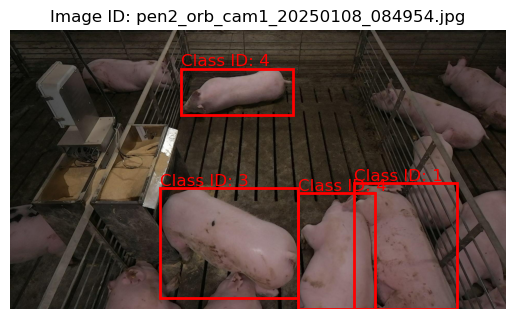

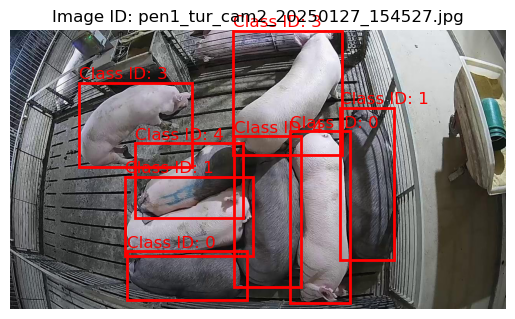

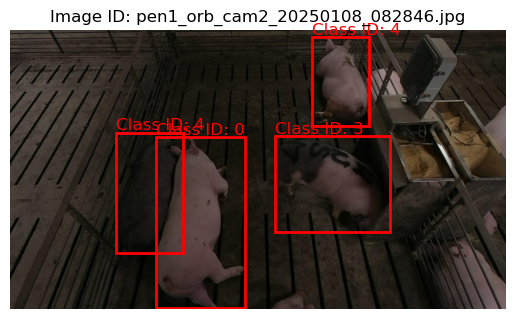

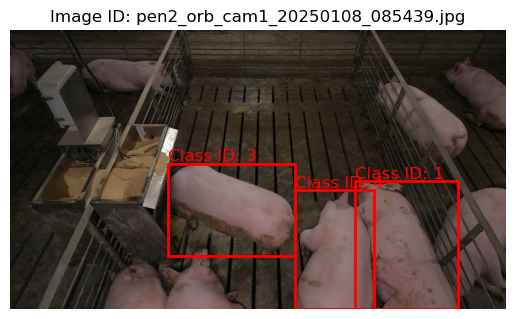

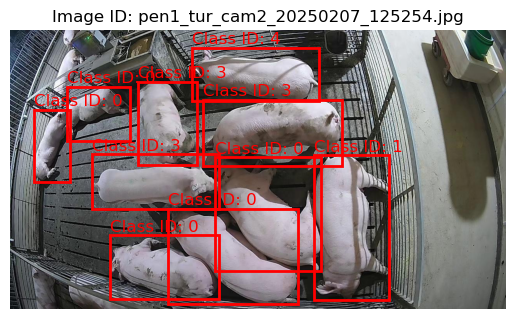

In [6]:
# show 5 random images from train1 or train 2with bounding boxes and class ids
def show_random_images_with_bboxes(df, images_path, num_images=5):
    random_images = df['image_id'].drop_duplicates().sample(num_images).values
    for image_id in random_images:
        image_path = os.path.join(images_path, image_id)
        image = Image.open(image_path)
        plt.imshow(image)
        plt.title(f"Image ID: {image_id}")
        plt.axis('off')
        
        # get bounding boxes and class ids for the image
        bboxes = df[df['image_id'] == image_id][['bbox', 'class_id']]
        
        for _, row in bboxes.iterrows():
            bbox = eval(row['bbox'])  # convert string to list
            class_id = row['class_id']
            x_min, y_min, width, height = bbox
            x_max = x_min + width
            y_max = y_min + height
            
            # draw bounding box
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), width, height, 
                                              edgecolor='red', facecolor='none', linewidth=2))
            plt.text(x_min, y_min - 10, f"Class ID: {class_id}", color='red', fontsize=12)
        
        plt.show()
show_random_images_with_bboxes(train1_df, train1_images_path)


### EDA 
Class Definitions:

0 — Lateral_lying_left

1 — Lateral_lying_right

2 — Sitting

3 — Standing

4 — Sternal_lying

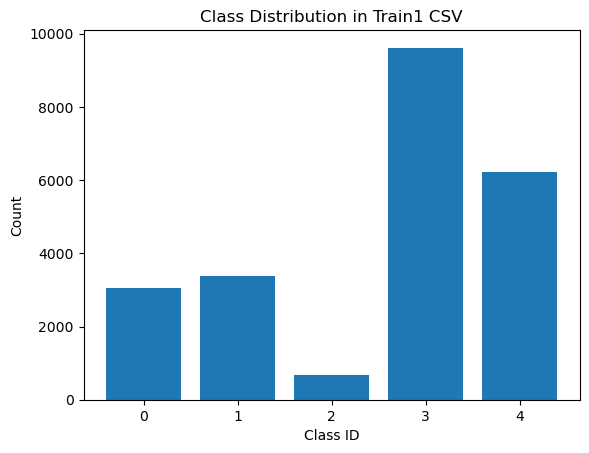

In [7]:
# analyze distribution of class ids in train1 and train2 csv files
def analyze_class_distribution(df, title):
    class_counts = df['class_id'].value_counts().sort_index()
    plt.bar(class_counts.index, class_counts.values)
    plt.xlabel('Class ID')
    plt.ylabel('Count')
    plt.title(title)
    plt.xticks(class_counts.index)
    plt.show()

analyze_class_distribution(train1_df, "Class Distribution in Train1 CSV")

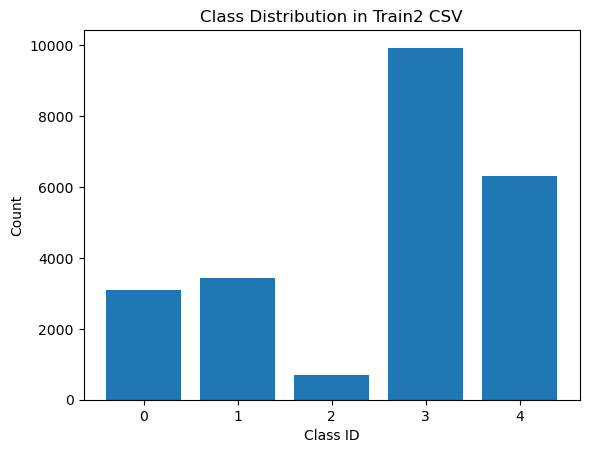

In [8]:
analyze_class_distribution(train2_df, "Class Distribution in Train2 CSV")


In [9]:
# show amount of class distribution in train1 and train2 csv files

train1_df_distribution = train1_df['class_id'].value_counts().sort_index()
train2_df_distribution = train2_df['class_id'].value_counts().sort_index()

print("\nClass Distribution in Train1 CSV:")
print(train1_df_distribution)
print("\nClass Distribution in Train2 CSV:")
print(train2_df_distribution)


Class Distribution in Train1 CSV:
class_id
0    3053
1    3376
2     680
3    9617
4    6208
Name: count, dtype: int64

Class Distribution in Train2 CSV:
class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64


### Klassen sind stark unausgewogen, insbesondere Sitting Class id = 2. Gegenmaßnahme ist notwendig, um die Minderheitsklasse nicht zu vernachlässigen.

In [10]:
# check if there are any missing values in train1 and train2 csv files
print("\nMissing values in Train1 CSV:")
print(train1_df.isnull().sum())
print("\nMissing values in Train2 CSV:")
print(train2_df.isnull().sum())


Missing values in Train1 CSV:
row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
dtype: int64

Missing values in Train2 CSV:
row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
dtype: int64


In [11]:
# check if unique values in "height" and "weight" columns in train1 and train2 csv files are the same
print("\nUnique values in 'height' column in Train1 CSV:")
print(train1_df['height'].unique())
print("\nUnique values in 'height' column in Train2 CSV:")
print(train2_df['height'].unique())
print("\nUnique values in 'width' column in Train1 CSV:")
print(train1_df['width'].unique())
print("\nUnique values in 'width' column in Train2 CSV:")
print(train2_df['width'].unique())


Unique values in 'height' column in Train1 CSV:
[1080  720 1520]

Unique values in 'height' column in Train2 CSV:
[1080  720 1520]

Unique values in 'width' column in Train1 CSV:
[1920 1280 2688]

Unique values in 'width' column in Train2 CSV:
[1920 1280 2688]


### Die Bilder liegen nur in drei Auflösungen vor: 1280 x 720, 1920 x 1080, 2688 x 1520. Vorverarbeitung ist konsistent planbar. 

In [12]:
# Blur-Score (OpenCV)
def blur_score(img_bgr):
    return cv2.Laplacian(img_bgr, cv2.CV_64F).var()

# Helligkeit in HSV
def mean_brightness(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    return float(hsv[...,2].mean())


In [13]:
# plot blur score and mean brightness for 100 random images in separate scatter plots
def plot_blur_brightness(df, images_path, num_images=100):
    random_images = df['image_id'].drop_duplicates().sample(num_images).values
    blur_scores = []
    brightness_values = []
    
    for image_id in random_images:
        image_path = os.path.join(images_path, image_id)
        img_bgr = cv2.imread(image_path)
        
        blur_scores.append(blur_score(img_bgr))
        brightness_values.append(mean_brightness(img_bgr))
    
    # Scatter plot for Blur Score
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(range(num_images), blur_scores, color='blue')
    plt.title('Blur Score of Random Images')
    plt.xlabel('Image Index')
    plt.ylabel('Blur Score')
    
    # Scatter plot for Mean Brightness
    plt.subplot(1, 2, 2)
    plt.scatter(range(num_images), brightness_values, color='orange')
    plt.title('Mean Brightness of Random Images')
    plt.xlabel('Image Index')
    plt.ylabel('Mean Brightness')
    
    plt.tight_layout()
    plt.show()


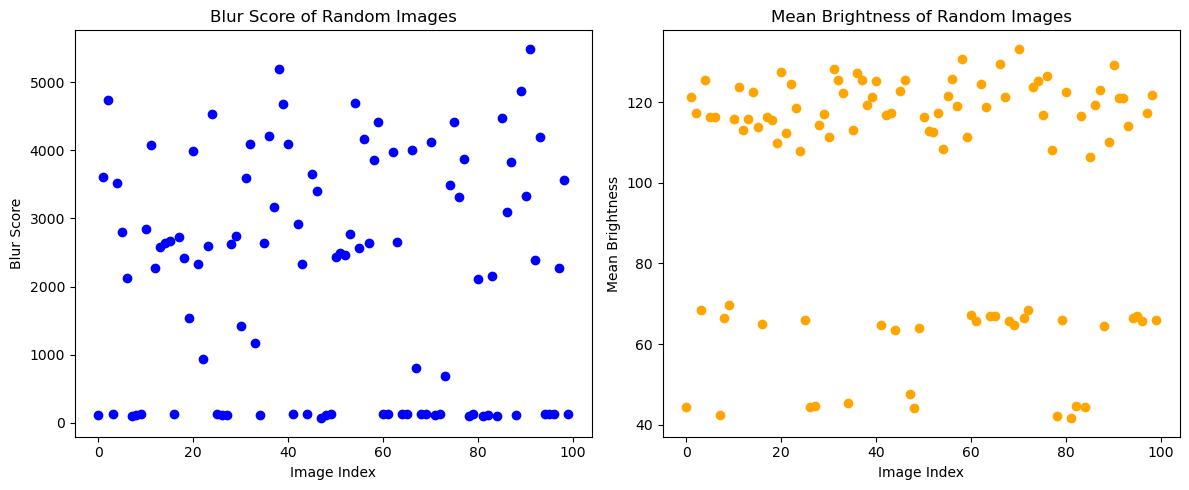

In [14]:
plot_blur_brightness(train1_df, train1_images_path)

### Fazit: Die EDA zeigt, dass die Klassen in den Trainingsdaten relativ ausgewogen verteilt sind, was für das Training eines Modells vorteilhaft ist. Es gibt keine fehlenden Werte in den CSV-Dateien, und die Bildgrößen sind konsistent. Die Analyse der Bildqualität anhand von Blur-Score und Helligkeit zeigt eine gewisse Variation. Im nächsten Schritt möchte ich die Kameras trennen und die Bilder entsprechend der Kamera analysieren, um mögliche Unterschiede in der Bildqualität oder den Aufnahmewinkeln zu identifizieren.

### Trennung der Kameras anhand der Bildnamen nur in Train1

In [15]:
def extract_pen_id(s: str):
    m = re.search(r'^(pen\d+)', s)
    return m.group(1) if m else None

def extract_camera_type(s: str):
    m = re.search(r'_(orb|tur)_', s)
    return m.group(1) if m else None

def extract_camera_number(s: str):
    m = re.search(r'cam(\d+)', s)
    return m.group(1) if m else None

# df1 = train1.csv als DataFrame; ersetze 'FILENAME_COL' durch deine Spalte (z. B. 'image', 'file_name', ...).
FILENAME_COL = "image_id"
train1_df["pen_id"]        = train1_df[FILENAME_COL].apply(extract_pen_id)
train1_df["camera_type"]   = train1_df[FILENAME_COL].apply(extract_camera_type)
train1_df["camera_number"] = train1_df[FILENAME_COL].apply(extract_camera_number)
train1_df["camera_view_id"]      = train1_df["pen_id"] + "_" + train1_df["camera_type"] + "_cam" + train1_df["camera_number"]


In [16]:
train1_df.head()

,row_id,image_id,width,height,bbox,class_id,pen_id,camera_type,camera_number,camera_view_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0,pen1,orb,1,pen1_orb_cam1
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4,pen1,orb,1,pen1_orb_cam1
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1,pen1,orb,1,pen1_orb_cam1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0,pen1,orb,1,pen1_orb_cam1
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3,pen1,orb,1,pen1_orb_cam1


In [17]:
# show unique values in camera_view_id column
print("\nUnique values in 'camera_view_id' column in Train1 CSV:")
print(train1_df['camera_view_id'].unique())



Unique values in 'camera_view_id' column in Train1 CSV:
['pen1_orb_cam1' 'pen1_orb_cam2' 'pen1_tur_cam2' 'pen2_orb_cam1'
 'pen2_tur_cam1']


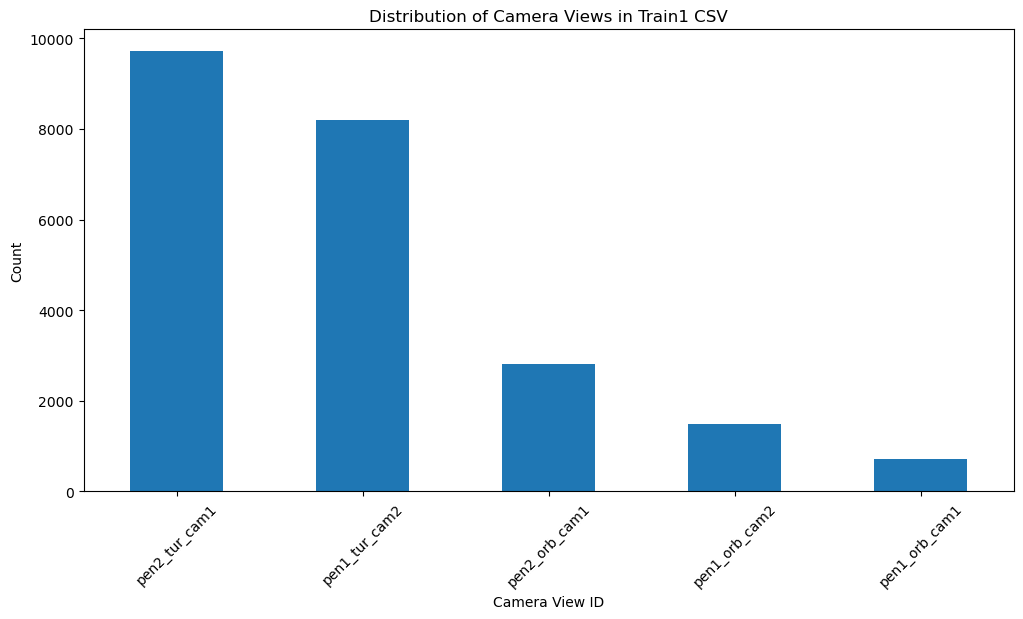

In [18]:
# plot the distribution of camera_view_id in train1_df
camera_view_counts = train1_df['camera_view_id'].value_counts()
plt.figure(figsize=(12, 6))
camera_view_counts.plot(kind='bar')
plt.title('Distribution of Camera Views in Train1 CSV')
plt.xlabel('Camera View ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [19]:
# show amount of images per camera view from train1_df
train1_camera_view_counts = train1_df['camera_view_id'].value_counts()
train1_camera_view_counts = train1_camera_view_counts.reset_index()
train1_camera_view_counts.columns = ['camera_view_id', 'image_count']
train1_camera_view_counts = train1_camera_view_counts.sort_values(by='image_count', ascending=False)
train1_camera_view_counts

,camera_view_id,image_count
0,pen2_tur_cam1,9713
1,pen1_tur_cam2,8194
2,pen2_orb_cam1,2817
3,pen1_orb_cam2,1488
4,pen1_orb_cam1,722


### Trennung der Kameras anhand der Bildnamen nur in Train2

In [20]:
train2_df["pen_id"]        = train2_df["image_id"].apply(extract_pen_id)
train2_df["camera_type"]   = train2_df["image_id"].apply(extract_camera_type)
train2_df["camera_number"] = train2_df["image_id"].apply(extract_camera_number)
train2_df["camera_view_id"]      = train2_df["pen_id"] + "_" + train2_df["camera_type"] + "_cam" + train2_df["camera_number"]


In [21]:
# show unique values in camera_view_id column
print("\nUnique values in 'camera_view_id' column in Train2 CSV:")
print(train2_df['camera_view_id'].unique())



Unique values in 'camera_view_id' column in Train2 CSV:
['pen1_orb_cam1' 'pen1_orb_cam2' 'pen1_tur_cam1' 'pen1_tur_cam2'
 'pen2_orb_cam1' 'pen2_orb_cam2' 'pen2_tur_cam1' 'pen2_tur_cam2']


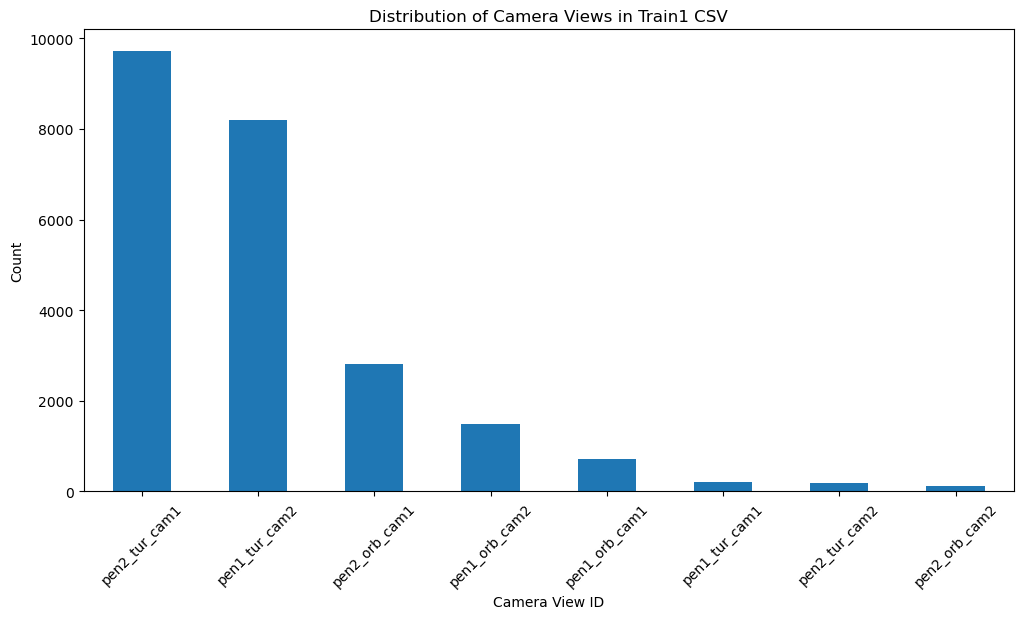

In [22]:
# plot the distribution of camera_view_id in train1_df
camera_view_counts = train2_df['camera_view_id'].value_counts()
plt.figure(figsize=(12, 6))
camera_view_counts.plot(kind='bar')
plt.title('Distribution of Camera Views in Train1 CSV')
plt.xlabel('Camera View ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [23]:
# show amount of images per camera view from train2_df
train2_camera_view_counts = train2_df['camera_view_id'].value_counts()
train2_camera_view_counts = train2_camera_view_counts.reset_index()
train2_camera_view_counts.columns = ['camera_view_id', 'image_count']
train2_camera_view_counts = train2_camera_view_counts.sort_values(by='image_count', ascending=False)
train2_camera_view_counts


,camera_view_id,image_count
0,pen2_tur_cam1,9713
1,pen1_tur_cam2,8194
2,pen2_orb_cam1,2817
3,pen1_orb_cam2,1488
4,pen1_orb_cam1,722
5,pen1_tur_cam1,200
6,pen2_tur_cam2,196
7,pen2_orb_cam2,120
